In [2]:
import numpy as np 
import pandas as pd 
from sklearn.model_selection import train_test_split 
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text 
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,confusion_matrix, classification_report 
import matplotlib.pyplot as plt 

In [3]:
df = pd.read_csv('your_file.csv') 
print(df.head())

   Experience  Education  Age  Salary
0           1         12   22   25000
1           2         12   24   30000
2           3         14   26   38000
3           4         14   28   45000
4           5         15   30   52000


In [6]:
# Create 3-Class Target from Salary 
# 0 = Low, 1 = Medium, 2 = High 
salary = df['Salary'] 
conditions = [ 
salary < 45000, 
(salary >= 45000) & (salary < 75000), 
salary >= 75000 
] 

In [7]:
choices = [0, 1, 2] 
df['SalaryClass'] = np.select(conditions, choices) 

In [8]:
# Features and Target 
X = df[['Experience', 'Education', 'Age']] 
y = df['SalaryClass'] 

In [10]:
# Train-Test Split 
X_train, X_test, y_train, y_test = train_test_split( 
X, y, test_size=0.3, random_state=42, stratify=y 
) 

In [11]:
# ID3 uses Information Gain (entropy) for splitting 
id3_tree = DecisionTreeClassifier(criterion='entropy', random_state=42) 
id3_tree.fit(X_train, y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [12]:
y_pred_id3 = id3_tree.predict(X_test)

In [13]:
acc_id3 = accuracy_score(y_test, y_pred_id3) 
prec_id3 = precision_score(y_test, y_pred_id3, average='macro', zero_division=0) 
rec_id3  = recall_score(y_test, y_pred_id3, average='macro', zero_division=0) 
f1_id3   = f1_score(y_test, y_pred_id3, average='macro', zero_division=0)

In [20]:
print('===== ID3 (Entropy) Results =====') 
print('Accuracy :', acc_id3) 
print('Precision:', prec_id3) 
print('Recall   :', rec_id3) 
print('F1-score :', f1_id3) 
print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred_id3)) 
print('\nClassification Report:\n', classification_report(y_test, y_pred_id3,zero_division=0))

===== ID3 (Entropy) Results =====
Accuracy : 0.3333333333333333
Precision: 0.1111111111111111
Recall   : 0.3333333333333333
F1-score : 0.16666666666666666
Confusion Matrix:
 [[0 1 0]
 [0 1 0]
 [0 1 0]]

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.33      1.00      0.50         1
           2       0.00      0.00      0.00         1

    accuracy                           0.33         3
   macro avg       0.11      0.33      0.17         3
weighted avg       0.11      0.33      0.17         3



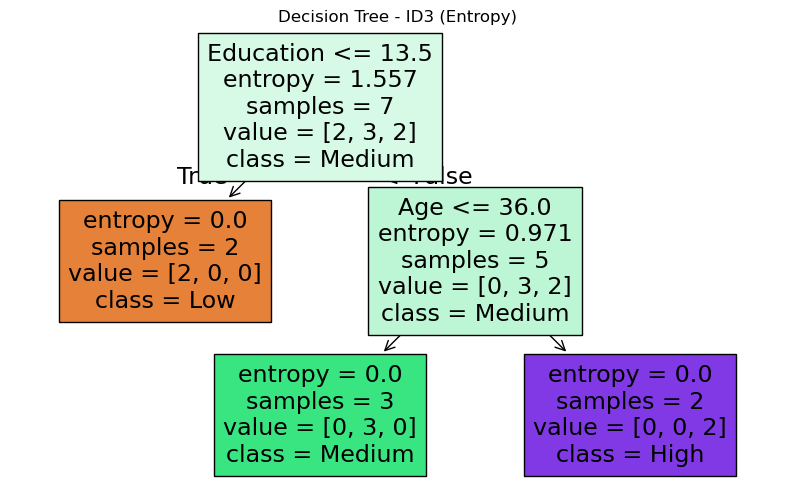

In [21]:
# Plot Tree (ID3) 
plt.figure(figsize=(10, 6)) 
plot_tree(id3_tree, feature_names=X.columns, class_names=['Low','Medium','High'], 
filled=True) 
plt.title('Decision Tree - ID3 (Entropy)') 
plt.show()

In [22]:
# Text Tree (ID3) 
print(export_text(id3_tree, feature_names=list(X.columns)))

|--- Education <= 13.50
|   |--- class: 0
|--- Education >  13.50
|   |--- Age <= 36.00
|   |   |--- class: 1
|   |--- Age >  36.00
|   |   |--- class: 2



In [23]:
# CART uses Gini Impurity (binary splits) 
cart_tree = DecisionTreeClassifier(criterion='gini', random_state=42) 
cart_tree.fit(X_train, y_train) 

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [24]:
y_pred_cart = cart_tree.predict(X_test)

In [25]:
acc_cart = accuracy_score(y_test, y_pred_cart) 
prec_cart = precision_score(y_test, y_pred_cart, average='macro', zero_division=0) 
rec_cart  = recall_score(y_test, y_pred_cart, average='macro', zero_division=0) 
f1_cart   = f1_score(y_test, y_pred_cart, average='macro', zero_division=0) 

In [26]:
print('===== CART (Gini) Results =====') 
print('Accuracy :', acc_cart) 
print('Precision:', prec_cart) 
print('Recall   :', rec_cart) 
print('F1-score :', f1_cart) 
print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred_cart)) 
print('\nClassification Report:\n', classification_report(y_test, y_pred_cart,zero_division=0)) 

===== CART (Gini) Results =====
Accuracy : 0.3333333333333333
Precision: 0.1111111111111111
Recall   : 0.3333333333333333
F1-score : 0.16666666666666666
Confusion Matrix:
 [[0 1 0]
 [0 1 0]
 [0 1 0]]

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.33      1.00      0.50         1
           2       0.00      0.00      0.00         1

    accuracy                           0.33         3
   macro avg       0.11      0.33      0.17         3
weighted avg       0.11      0.33      0.17         3



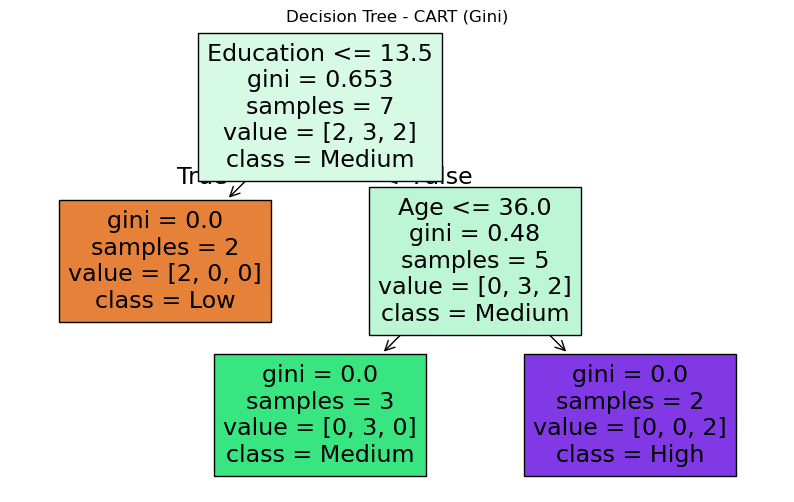

In [27]:
# Plot Tree (CART) 
plt.figure(figsize=(10, 6)) 
plot_tree(cart_tree, feature_names=X.columns, class_names=['Low','Medium','High'], 
filled=True) 
plt.title('Decision Tree - CART (Gini)') 
plt.show()

In [28]:
print(export_text(cart_tree, feature_names=list(X.columns))) 

|--- Education <= 13.50
|   |--- class: 0
|--- Education >  13.50
|   |--- Age <= 36.00
|   |   |--- class: 1
|   |--- Age >  36.00
|   |   |--- class: 2

